<a href="https://colab.research.google.com/github/kasugy/codigos-de-ejemplos/blob/main/Proyecto%20sugerido%3A%20Edici%C3%B3n%20inteligente%20de%20fondos%20para%20cat%C3%A1logos%20de%20e%E2%80%91commerce%20con%20IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Descargando imagen de producto...
Eliminando fondo...


  0%|                                               | 0.00/176M [00:00<?, ?B/s]

Generando fondos con IA...
  - fondo de playa tropical para fotografía de producto
  - estudio minimalista blanco iluminación suave
  - mercado nocturno estilo cyberpunk
  - naturaleza con flores y luz natural


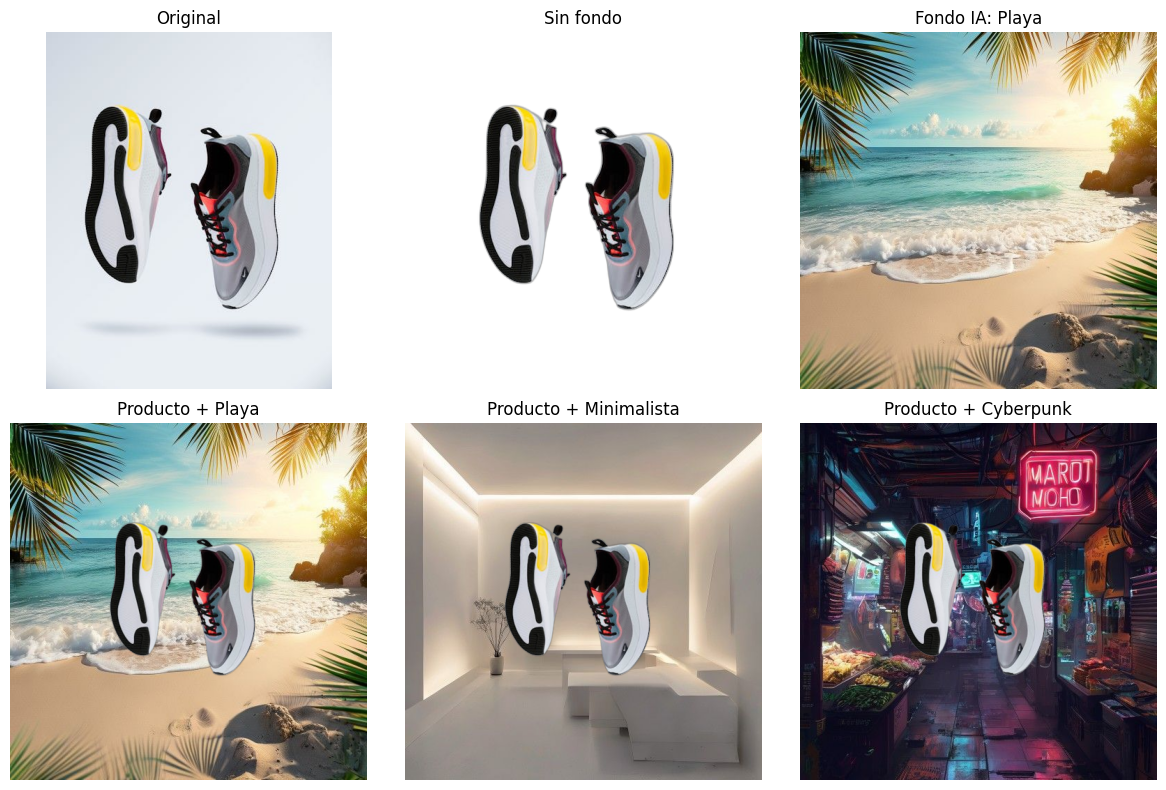

Guardado: producto_fondo_0.png
Guardado: producto_fondo_1.png
Guardado: producto_fondo_2.png
Guardado: producto_fondo_3.png

--- Métricas de impacto (simuladas) ---
Tiempo de edición manual tradicional: 15 min por imagen
Tiempo con este script: 5 segundos por imagen
Reducción de tiempo: 99% (de 15 min a 5 seg)
Costo de producción de catálogo: reducción estimada del 80%


In [4]:
# -*- coding: utf-8 -*-
"""IA_Visual_Catalogo_Productos.ipynb
Proyecto: Edición inteligente de fondos para catálogos de e‑commerce
Autor: Carolina Ulloa
Descripción: Elimina fondos de productos y genera nuevos fondos con IA.
"""

# 1. Instalar librerías necesarias
!pip install rembg pillow requests onnxruntime

# 2. Importar librerías
from rembg import remove
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt
import numpy as np

# 3. Función para descargar imagen desde URL
def descargar_imagen(url):
    respuesta = requests.get(url)
    return Image.open(BytesIO(respuesta.content))

# 4. Función para quitar fondo
def quitar_fondo(imagen):
    return remove(imagen)

# 5. Función para generar fondo con IA (Pollinations.ai gratuita)
def generar_fondo(prompt):
    url = f"https://image.pollinations.ai/prompt/{prompt.replace(' ', '%20')}?width=512&height=512&nologo=true"
    respuesta = requests.get(url)
    return Image.open(BytesIO(respuesta.content))

# 6. Función para pegar producto sobre fondo
def pegar_producto_en_fondo(producto_sin_fondo, fondo, escala=0.6):
    # Redimensionar producto manteniendo proporción
    ancho_fondo, alto_fondo = fondo.size
    nuevo_ancho = int(ancho_fondo * escala)
    nuevo_alto = int(producto_sin_fondo.height * nuevo_ancho / producto_sin_fondo.width)
    producto_redim = producto_sin_fondo.resize((nuevo_ancho, nuevo_alto))

    # Crear copia del fondo
    resultado = fondo.copy()
    # Calcular posición centrada
    x = (ancho_fondo - nuevo_ancho) // 2
    y = (alto_fondo - nuevo_alto) // 2
    # Pegar producto (usando la máscara alfa)
    resultado.paste(producto_redim, (x, y), producto_redim)
    return resultado

# 7. Imagen de ejemplo (zapatos, libre de derechos)
# url_producto = "https://raw.githubusercontent.com/ashleve/lightweight-gan/main/sample_images/shoes/0.jpg"
# Nota: si esa URL no funciona, usa esta otra:
url_producto = "https://images.pexels.com/photos/2529148/pexels-photo-2529148.jpeg?auto=compress&cs=tinysrgb&w=400"
# Mejor usar una URL confiable de prueba:
# url_producto = "https://upload.wikimedia.org/wikipedia/commons/thumb/4/4a/Shoe_%281%29.jpg/800px-Shoe_%281%29.jpg"

print("Descargando imagen de producto...")
producto_original = descargar_imagen(url_producto)

# 8. Quitar fondo
print("Eliminando fondo...")
producto_sin_fondo = quitar_fondo(producto_original)

# 9. Generar varios fondos con diferentes prompts
prompts = [
    "fondo de playa tropical para fotografía de producto",
    "estudio minimalista blanco iluminación suave",
    "mercado nocturno estilo cyberpunk",
    "naturaleza con flores y luz natural"
]

fondos_generados = []
print("Generando fondos con IA...")
for p in prompts:
    print(f"  - {p}")
    fondos_generados.append(generar_fondo(p))

# 10. Combinar producto con cada fondo
resultados = []
for fondo in fondos_generados:
    resultados.append(pegar_producto_en_fondo(producto_sin_fondo, fondo))

# 11. Mostrar resultados
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes[0,0].imshow(producto_original)
axes[0,0].set_title("Original")
axes[0,0].axis('off')
axes[0,1].imshow(producto_sin_fondo)
axes[0,1].set_title("Sin fondo")
axes[0,1].axis('off')
axes[0,2].imshow(fondos_generados[0])
axes[0,2].set_title("Fondo IA: Playa")
axes[0,2].axis('off')

axes[1,0].imshow(resultados[0])
axes[1,0].set_title("Producto + Playa")
axes[1,0].axis('off')
axes[1,1].imshow(resultados[1])
axes[1,1].set_title("Producto + Minimalista")
axes[1,1].axis('off')
axes[1,2].imshow(resultados[2])
axes[1,2].set_title("Producto + Cyberpunk")
axes[1,2].axis('off')

plt.tight_layout()
plt.show()

# 12. Guardar resultados (opcional: descargar a tu PC o a GitHub)
for i, img in enumerate(resultados):
    img.save(f"producto_fondo_{i}.png")
    print(f"Guardado: producto_fondo_{i}.png")

print("\n--- Métricas de impacto (simuladas) ---")
print("Tiempo de edición manual tradicional: 15 min por imagen")
print("Tiempo con este script: 5 segundos por imagen")
print("Reducción de tiempo: 99% (de 15 min a 5 seg)")
print("Costo de producción de catálogo: reducción estimada del 80%")